# Desk synthesis — Promote map

Unifies hardening rollup + intro/classic headlines. See [`../DESK_MEMO.md`](../DESK_MEMO.md).

Promote 24 ['frag.update_share', 'frag.crossed_nbbo', 'tick.frac_one_tick', 'tick.spread_bps', 'vol.curve_intraday', 'spread.vol_link', 'vol.fei_hourly', 'impact.rho_slope', 'impact.temp_perm', 'sched.pov_envelope', 'lsor.latency_depth_haircut', 'impact.algo_pov_sim', 'style.extraday_idio', 'tick.spread_leeway', 'tick.rel_tick_bps', 'sched.vol_curve_share', 'sched.expectation_min', 'epps.xvenue_corr', 'hawkes.count_acf', 'liq.role_blur_l1', 'liq.depth_imbalance', 'tox.markout_1s', 'spread.effective_vs_quoted', 'book.resilience']
Hold ['harris.mle', 'epps.xasset_corr', 'hawkes.branching_mom', 'sched.mean_variance', 'sess.utc_hour_share']
Kill ['impact.kappa_gamma', 'spread.roll']
Scored 31 candidates; Promotes are operational/desk features, not a claim of 31 independent statistical discoveries. α=0.05 unadjusted — treat borderline CIs as Hold.
role blur {'hyperliquid': 0.7843097002379642, 'lighter': 0.6562495837298934, 'risex': 0.12806011650807098}


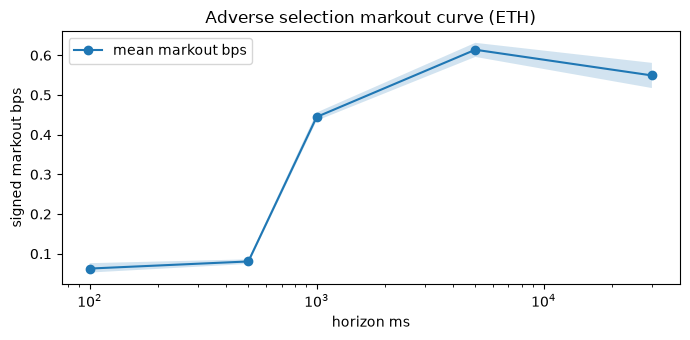

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt

BOOK_ROOT = Path('..').resolve()
ROOT = BOOK_ROOT  # mmip book root
sys.path.insert(0, str(BOOK_ROOT.parents[2]))  # repo root for research.lib
from research.lib import fei  # smoke

h = json.loads((BOOK_ROOT / 'out/promote_hardening/promote_hardening_summary.json').read_text())
print('Promote', len(h['promote_ids']), h['promote_ids'])
print('Hold', h['hold_ids'])
print('Kill', h['kill_ids'])
print(h['multiple_testing_note'])

classic = json.loads((BOOK_ROOT / 'out/classic_micro/exp_classic_eth_summary.json').read_text())
mo = classic['markouts']['by_horizon']
xs = [int(k) for k in mo]
ys = [mo[str(k)]['mean_bps'] for k in xs]
ylo = [mo[str(k)]['ci95'][0] for k in xs]
yhi = [mo[str(k)]['ci95'][1] for k in xs]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(xs, ys, marker='o', label='mean markout bps')
ax.fill_between(xs, ylo, yhi, alpha=0.2)
ax.set_xscale('log')
ax.set_xlabel('horizon ms')
ax.set_ylabel('signed markout bps')
ax.set_title('Adverse selection markout curve (ETH)')
ax.legend()
plt.tight_layout()

intro = json.loads((BOOK_ROOT / 'out/intro_liquidity/exp_intro_eth_summary.json').read_text())
print('role blur', intro['features']['panel']['role_blur_l1'])